<a href="https://colab.research.google.com/github/kreitika/Retail-Strategy-Analytics-UCI-Online-Retail-Dataset/blob/main/RetailStrategyAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to file in your Google Drive
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Online Retail.xlsx')
df.head()


Mounted at /content/drive


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
!pip install duckdb lifetimes mlxtend pyarrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 10.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt


In [ ]:
# Path to file in Google Drive
file_path = '/content/drive/MyDrive/Online Retail.xlsx'

# Load into pandas
df = pd.read_excel(file_path)

# Show first 5 rows
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [ ]:
# Making a safe working copy so we never break the original
df_raw = df.copy()

# Stripping extra spaces and force consistent text for a few columns
for col in ['InvoiceNo', 'StockCode', 'Description', 'Country']:
    df_raw[col] = df_raw[col].astype(str).str.strip()

# Parsing InvoiceDate into a real datetime
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'], errors='coerce')

df_raw.head(3)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
# Invoices starting with 'C' are cancellations/returns
is_return = df_raw['InvoiceNo'].str.startswith('C', na=False)

df_returns = df_raw[is_return].copy()       # keeping for later analysis
df_main    = df_raw[~is_return].copy()      # our main analysis data

len(df_returns), len(df_main)


(9288, 532621)

In [ ]:
mask_valid = (
    (df_main['Quantity'] > 0) &
    (df_main['UnitPrice'] > 0) &
    (~df_main['CustomerID'].isna()) &
    (df_main['InvoiceDate'].notna())
)

df_main = df_main[mask_valid].copy()

# Making CustomerID an integer
df_main['CustomerID'] = df_main['CustomerID'].astype(int)

df_main.shape


(397884, 8)

In [ ]:
df_main['Revenue'] = df_main['Quantity'] * df_main['UnitPrice']

summary = {
    'rows': len(df_main),
    'unique_customers': df_main['CustomerID'].nunique(),
    'unique_invoices': df_main['InvoiceNo'].nunique(),
    'unique_skus': df_main['StockCode'].nunique(),
    'date_min': df_main['InvoiceDate'].min(),
    'date_max': df_main['InvoiceDate'].max(),
    'total_revenue': df_main['Revenue'].sum()
}
summary


{'rows': 397884,
 'unique_customers': 4338,
 'unique_invoices': 18532,
 'unique_skus': 3665,
 'date_min': Timestamp('2010-12-01 08:26:00'),
 'date_max': Timestamp('2011-12-09 12:50:00'),
 'total_revenue': np.float64(8911407.904)}

In [ ]:
def iqr_cap(series, low_q=0.01, high_q=0.99, k=1.5):
    q1, q3 = series.quantile([low_q, high_q])
    iqr = q3 - q1
    lower = max(series.quantile(0.01), q1 - k*iqr)
    upper = min(series.quantile(0.99), q3 + k*iqr)
    return series.clip(lower, upper)

df_main['Quantity']  = iqr_cap(df_main['Quantity'].astype(float))
df_main['UnitPrice'] = iqr_cap(df_main['UnitPrice'].astype(float))

# Recomputing revenue after capping
df_main['Revenue'] = df_main['Quantity'] * df_main['UnitPrice']
df_main[['Quantity','UnitPrice','Revenue']].describe()


,Quantity,UnitPrice,Revenue
count,397884.000000,397884.000000,397884.000000
mean,10.914204,2.828071,19.281979
std,18.076242,2.785392,37.295530
min,1.000000,0.210000,0.210000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,11.850000
75%,12.000000,3.750000,19.800000
max,120.000000,14.950000,1794.000000


In [ ]:
# Removing exact duplicates (very safe dedup)
before = len(df_main)
df_main = df_main.drop_duplicates()
after = len(df_main)

# Adding time helpers
df_main['InvoiceDate'] = pd.to_datetime(df_main['InvoiceDate'])
df_main['InvoiceDateOnly'] = df_main['InvoiceDate'].dt.date
df_main['Year']   = df_main['InvoiceDate'].dt.year
df_main['Month']  = df_main['InvoiceDate'].dt.month
df_main['Day']    = df_main['InvoiceDate'].dt.day
df_main['Hour']   = df_main['InvoiceDate'].dt.hour
df_main['DoW']    = df_main['InvoiceDate'].dt.dayofweek  # 0=Mon

{'duplicates_removed': before - after, 'rows_now': after}


{'duplicates_removed': 5207, 'rows_now': 392677}

/tmp/ipython-input-3666941170.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='InvoiceDate', freq='M'))


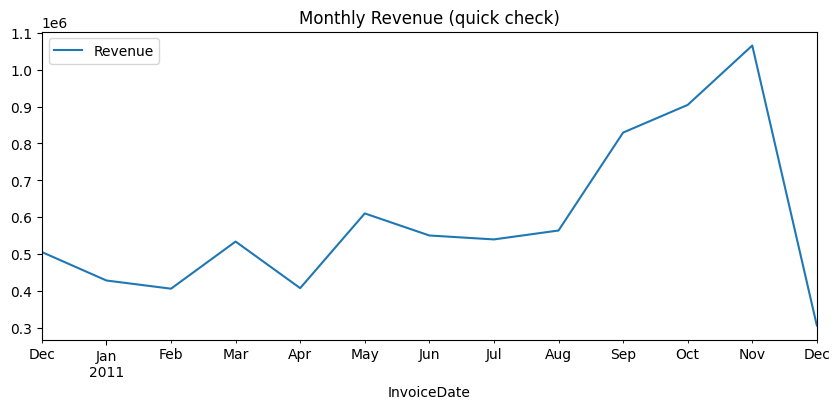

In [ ]:
monthly = (df_main
           .groupby(pd.Grouper(key='InvoiceDate', freq='M'))
           .agg(Revenue=('Revenue','sum'))
           .reset_index())

monthly.plot(x='InvoiceDate', y='Revenue', figsize=(10,4), title='Monthly Revenue (quick check)');


In [ ]:
import os

base_dir = '/content/drive/MyDrive/retail-analytics'
export_dir = f'{base_dir}/exports'
os.makedirs(export_dir, exist_ok=True)

clean_csv    = f'{export_dir}/fact_sales_clean.csv'
clean_parquet= f'{export_dir}/fact_sales_clean.parquet'

df_main.to_csv(clean_csv, index=False)
df_main.to_parquet(clean_parquet, index=False)

clean_csv, clean_parquet


('/content/drive/MyDrive/retail-analytics/exports/fact_sales_clean.csv',
 '/content/drive/MyDrive/retail-analytics/exports/fact_sales_clean.parquet')

In [ ]:
# dim_customer (basic)
dim_customer = (df_main.groupby('CustomerID')
                .agg(FirstPurchase=('InvoiceDate','min'),
                     LastPurchase=('InvoiceDate','max'),
                     Orders=('InvoiceNo','nunique'),
                     TotalRevenue=('Revenue','sum'),
                     AvgOrderValue=('Revenue','mean'))
                .reset_index())

# dim_product (basic)
dim_product = (df_main.groupby(['StockCode','Description'])
               .agg(Units=('Quantity','sum'),
                    Revenue=('Revenue','sum'),
                    AvgPrice=('UnitPrice','mean'))
               .reset_index())

dim_dir = f'{base_dir}/exports'
dim_customer.to_parquet(f'{dim_dir}/dim_customer.parquet', index=False)
dim_product.to_parquet(f'{dim_dir}/dim_product.parquet', index=False)

len(dim_customer), len(dim_product)


(4338, 3894)

In [ ]:
import pandas as pd
import numpy as np

# Using the cleaned main dataset from Step 2
sales = df_main.copy()

# Snapshot = day after last purchase in our data
snapshot_date = sales['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM table
rfm = (sales.groupby('CustomerID')
       .agg(
           Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
           Frequency=('InvoiceNo', pd.Series.nunique),
           Monetary=('Revenue', 'sum')
       )
       .reset_index())

rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,124.80
1,12347,2,7,4185.20
2,12348,75,4,1530.03
3,12349,19,1,1443.50
4,12350,310,1,309.35


In [ ]:
# Recency: smaller is better → 5 = recent, 1 = old
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)

# Frequency: bigger is better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

# Monetary: bigger is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

# Add total
rfm['RFM_Sum'] = rfm[['R_Score','F_Score','M_Score']].sum(axis=1)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Sum
0,12346,326,1,124.80,1,1,1,3
1,12347,2,7,4185.20,5,5,5,15
2,12348,75,4,1530.03,2,4,4,10
3,12349,19,1,1443.50,4,1,4,9
4,12350,310,1,309.35,1,1,2,4


In [ ]:
def label_customer(r, f, m):
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 3:
        return 'Loyal'
    elif r <= 2 and f <= 2:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = [label_customer(r,f,m) for r,f,m in rfm[['R_Score','F_Score','M_Score']].to_numpy()]

rfm['Segment'].value_counts()


,count
Segment,
Regular,1820
At Risk,1065
Champions,964
Loyal,489


In [ ]:
seg_summary = (rfm.groupby('Segment')
               .agg(Customers=('CustomerID','count'),
                    AvgRevenue=('Monetary','mean'),
                    TotalRevenue=('Monetary','sum'))
               .sort_values('TotalRevenue', ascending=False))

seg_summary


,Customers,AvgRevenue,TotalRevenue
Segment,,,
Champions,964,5277.326400,5087342.65
Regular,1820,992.218747,1805838.12
At Risk,1065,383.950977,408907.79
Loyal,489,705.640859,345058.38


In [ ]:
rfm.to_csv(f'{export_dir}/rfm_scores.csv', index=False)
seg_summary.to_csv(f'{export_dir}/rfm_summary.csv')


<Axes: title={'center': 'Customer Segments'}, ylabel='Customers'>

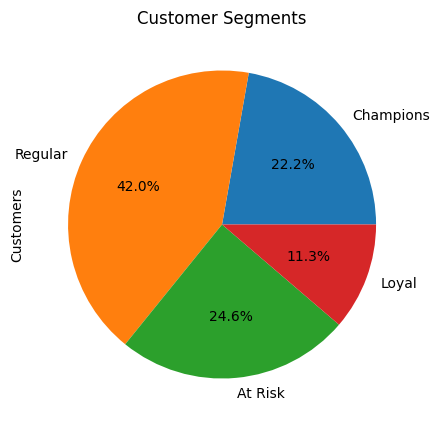

In [ ]:
seg_summary['Customers'].plot.pie(autopct='%1.1f%%', figsize=(5,5), title='Customer Segments')


In [ ]:
# Working from the cleaned main dataset
sales = df_main.copy()

# Let's assume cost is ~70% of price (so margin = 30%)
assumed_cost_rate = 0.70

# Product-level aggregation
prod = (sales.groupby(['StockCode','Description'], as_index=False)
        .agg(Units=('Quantity','sum'),
             Revenue=('Revenue','sum'),
             AvgPrice=('UnitPrice','mean')))

# Adding margin columns
prod['GrossMargin'] = prod['Revenue'] * (1 - assumed_cost_rate)
prod['MarginRate'] = prod['GrossMargin'] / prod['Revenue']

prod.head(5)


,StockCode,Description,Units,Revenue,AvgPrice,GrossMargin,MarginRate
0,10002,INFLATABLE POLITICAL GLOBE,823.0,699.55,0.850000,209.865,0.3
1,10080,GROOVY CACTUS INFLATABLE,291.0,114.41,0.411905,34.323,0.3
2,10120,DOGGY RUBBER,192.0,40.32,0.210000,12.096,0.3
3,10123C,HEARTS WRAPPING TAPE,5.0,3.25,0.650000,0.975,0.3
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16.0,6.72,0.420000,2.016,0.3


In [ ]:
# Threshold for bottom 10% margin rate
threshold = prod['MarginRate'].quantile(0.10)

low_margin = prod[prod['MarginRate'] <= threshold].copy()
high_margin = prod[prod['MarginRate'] > threshold].copy()

print("Low-margin SKUs:", len(low_margin))
low_margin.sort_values('MarginRate').head(10)


Low-margin SKUs: 3839


,StockCode,Description,Units,Revenue,AvgPrice,GrossMargin,MarginRate
3784,90175D,TIGRIS EYE CHUNKY CHARM BRACELET,3.0,26.85,8.950000,8.055,0.3
3763,90161B,ANT COPPER TURQ BOUDICCA BRACELET,45.0,222.75,4.950000,66.825,0.3
3764,90161C,ANT COPPER LIME BOUDICCA BRACELET,45.0,222.75,4.950000,66.825,0.3
3700,90116,FRUIT SALAD BAG CHARM,16.0,27.04,1.690000,8.112,0.3
3683,90084,PINK CRYSTAL GUITAR PHONE CHARM,1.0,0.85,0.850000,0.255,0.3
3697,90104,PURPLE FRANGIPANI HAIRCLIP,1.0,0.85,0.850000,0.255,0.3
3300,84925F,PSYCHEDELIC WALL THERMOMETER,79.0,109.93,1.921429,32.979,0.3
3305,84927A,WAKE UP COCKEREL TILE HOOK,46.0,53.85,1.489286,16.155,0.3
3262,84865,NEW BAROQUE BLACK PHOTO ALBUM,24.0,109.65,5.977273,32.895,0.3
3221,84802A,WHITE ANEMONE ARTIFICIAL FLOWER,2.0,3.38,1.690000,1.014,0.3


In [ ]:
rev_low = low_margin['Revenue'].sum()
rev_total = prod['Revenue'].sum()
print(f"Low-margin products contribute {rev_low/rev_total:.2%} of total revenue")


Low-margin products contribute 98.74% of total revenue


/tmp/ipython-input-726131031.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='InvoiceDate', freq='M'))


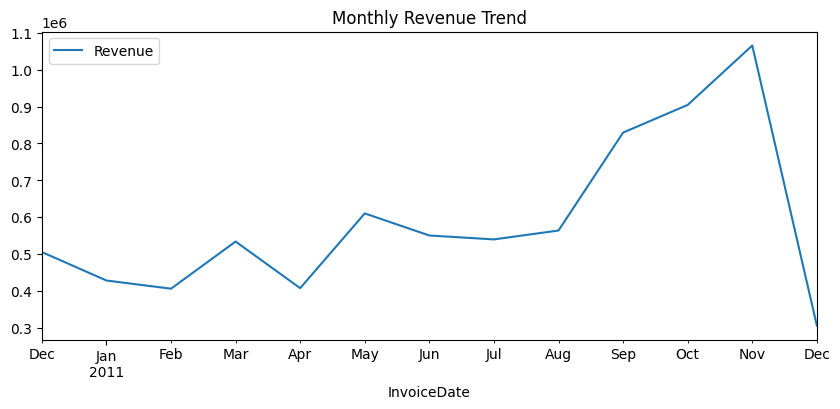

In [ ]:
monthly = (sales
           .groupby(pd.Grouper(key='InvoiceDate', freq='M'))
           .agg(Revenue=('Revenue','sum'),
                Orders=('InvoiceNo','nunique'),
                Customers=('CustomerID','nunique'))
           .reset_index())

monthly.plot(x='InvoiceDate', y='Revenue', figsize=(10,4), title='Monthly Revenue Trend');


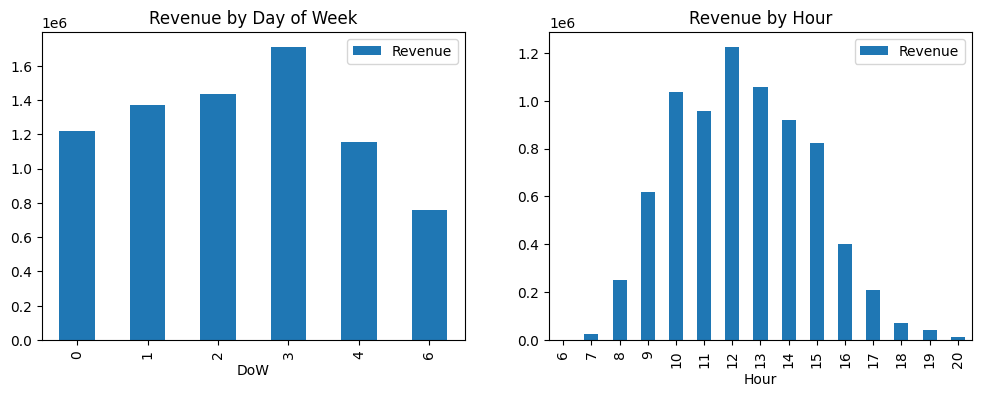

In [ ]:
# Day of week (0=Mon)
dow = (sales.groupby('DoW')
       .agg(Revenue=('Revenue','sum'))
       .reset_index())

# Hour of day
hourly = (sales.groupby('Hour')
          .agg(Revenue=('Revenue','sum'))
          .reset_index())

fig, ax = plt.subplots(1,2, figsize=(12,4))
dow.plot(x='DoW', y='Revenue', kind='bar', ax=ax[0], title='Revenue by Day of Week')
hourly.plot(x='Hour', y='Revenue', kind='bar', ax=ax[1], title='Revenue by Hour')
plt.show()


In [ ]:
low_margin.to_csv(f'{export_dir}/low_margin_products.csv', index=False)
monthly.to_csv(f'{export_dir}/monthly_kpis.csv', index=False)


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Limiting to top 200 products (by unique orders) so it's not too wide
top_items = (sales.groupby('StockCode')['InvoiceNo']
             .nunique()
             .sort_values(ascending=False)
             .head(200)
             .index)

basket = (sales[sales['StockCode'].isin(top_items)]
          .groupby(['InvoiceNo','StockCode'])['Quantity']
          .sum()
          .unstack()       # pivot: invoices × products
          .fillna(0))

# Converting to 1/0 (did the customer buy or not)
basket = basket.applymap(lambda x: 1 if x>0 else 0)

basket.shape


/tmp/ipython-input-4105071840.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x>0 else 0)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use ti

(16408, 200)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Old (shows FutureWarning):
# basket = basket.applymap(lambda x: 1 if x>0 else 0)

# New: vectorized, no warning
basket = basket.gt(0)

# If you prefer 0/1 ints for CSV/export:
# basket = basket.gt(0).astype('uint8')

basket.shape, basket.memory_usage(deep=True).sum() / 1e6  # (rows, cols), MB


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

((16408, 200), np.float64(4.18404))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Minimum item support to keep (e.g., 1% of baskets)
min_item_support = 0.01
item_support = basket.mean(axis=0)  # since basket is boolean, mean = support
keep_cols = item_support[item_support >= min_item_support].index
basket = basket[keep_cols]

basket.shape, float(item_support[keep_cols].min())


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

((16408, 200), 0.02303754266211604)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

min_support = 0.02  # 2% of baskets; adjust if you want more or fewer rules

freq_items = apriori(
    basket,
    min_support=min_support,
    use_colnames=True,
    max_len=3   # limit to pairs/triples; remove or set to 2 if you only want pairs
)

freq_items.sort_values('support', ascending=False).head(10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
197,0.120551,(85123A)
80,0.103791,(22423)
194,0.097513,(85099B)
165,0.084044,(47566)
186,0.083801,(84879)
8,0.078559,(20725)
114,0.069844,(22720)
199,0.066980,(POST)
143,0.065822,(23203)
10,0.064115,(20727)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rules = association_rules(freq_items, metric="lift", min_threshold=1.05)

# Filter to practical, stronger rules
rules = rules[
    (rules['confidence'] >= 0.25) &   # at least 25% of the time
    (rules['lift'] >= 1.10)           # 10% better than random chance
].sort_values('lift', ascending=False)

rules.head(10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
115,(22698),"(22699, 22697)",0.033886,0.032972,0.023769,0.701439,21.273953,1.0,0.022652,3.238962,0.986420,0.551627,0.691259,0.711163
114,"(22699, 22697)",(22698),0.032972,0.033886,0.023769,0.720887,21.273953,1.0,0.022652,3.461376,0.985487,0.551627,0.711098,0.711163
113,"(22698, 22699)",(22697),0.026572,0.042114,0.023769,0.894495,21.240059,1.0,0.022650,9.079097,0.978932,0.529172,0.889857,0.729447
116,(22697),"(22698, 22699)",0.042114,0.026572,0.023769,0.564399,21.240059,1.0,0.022650,2.234679,0.994814,0.529172,0.552508,0.729447
79,(22697),(22698),0.042114,0.033886,0.028035,0.665702,19.645389,1.0,0.026608,2.889978,0.990825,0.584498,0.653977,0.746520
78,(22698),(22697),0.033886,0.042114,0.028035,0.827338,19.645389,1.0,0.026608,5.547759,0.982387,0.584498,0.819747,0.746520
112,"(22698, 22697)",(22699),0.028035,0.047721,0.023769,0.847826,17.766450,1.0,0.022431,6.257836,0.970934,0.457210,0.840200,0.672955
117,(22699),"(22698, 22697)",0.047721,0.028035,0.023769,0.498084,17.766450,1.0,0.022431,1.936510,0.991006,0.457210,0.483607,0.672955
82,(22698),(22699),0.033886,0.047721,0.026572,0.784173,16.432573,1.0,0.024955,4.412228,0.972085,0.482835,0.773357,0.670503
83,(22699),(22698),0.047721,0.033886,0.026572,0.556833,16.432573,1.0,0.024955,2.180021,0.986208,0.482835,0.541289,0.670503


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules.to_csv(f'{export_dir}/rules_basket.csv', index=False)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def set_to_list(s):
    try:
        return list(s)
    except TypeError:
        return [s]

for _, row in rules.head(5).iterrows():
    lhs = ", ".join(set_to_list(row['antecedents']))
    rhs = ", ".join(set_to_list(row['consequents']))
    print(f"If a customer buys [{lhs}] → they also buy [{rhs}] "
          f"(Support={row['support']:.2%}, Confidence={row['confidence']:.2%}, Lift={row['lift']:.2f})")


If a customer buys [22698] → they also buy [22699, 22697] (Support=2.38%, Confidence=70.14%, Lift=21.27)
If a customer buys [22699, 22697] → they also buy [22698] (Support=2.38%, Confidence=72.09%, Lift=21.27)
If a customer buys [22698, 22699] → they also buy [22697] (Support=2.38%, Confidence=89.45%, Lift=21.24)
If a customer buys [22697] → they also buy [22698, 22699] (Support=2.38%, Confidence=56.44%, Lift=21.24)
If a customer buys [22697] → they also buy [22698] (Support=2.80%, Confidence=66.57%, Lift=19.65)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
res = simulate_margin_uplift(cost_rate=0.70, drop_quantile=0.10, migrate_share=0.30)
res


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

NameError: name 'simulate_margin_uplift' is not defined

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd
import numpy as np

# Using the cleaned dataset built earlier in Step 2

sales = df_main.copy()

# tiny sanity check
sales[['InvoiceNo','StockCode','Quantity','UnitPrice','Revenue','InvoiceDate']].head(3)


,InvoiceNo,StockCode,Quantity,UnitPrice,Revenue,InvoiceDate
0,536365,85123A,6.0,2.55,15.30,2010-12-01 08:26:00
1,536365,71053,6.0,3.39,20.34,2010-12-01 08:26:00
2,536365,84406B,8.0,2.75,22.00,2010-12-01 08:26:00


In [ ]:
def simulate_margin_uplift(cost_rate=0.70, drop_quantile=0.10, migrate_share=0.30, topq_quantile=0.75):
    """
    cost_rate: assumed cost as % of price (0.70 = 70%)
    drop_quantile: bottom share of SKUs by margin rate to drop (0.10 = bottom 10%)
    migrate_share: share of dropped revenue that moves to 'good' SKUs (rest is lost)
    topq_quantile: where to migrate (top margin-rate quartile within kept SKUs)
    """
    # Product summary
    prod = (sales.groupby('StockCode', as_index=False)
            .agg(Revenue=('Revenue','sum')))
    prod['Margin'] = prod['Revenue'] * (1 - cost_rate)
    prod['MarginRate'] = prod['Margin'] / prod['Revenue']

    # Identify SKUs to drop (bottom-decile by MarginRate)
    cutoff = prod['MarginRate'].quantile(drop_quantile)
    keep = prod[prod['MarginRate'] > cutoff].copy()
    drop = prod[prod['MarginRate'] <= cutoff].copy()

    # Baseline margin
    base_margin = prod['Margin'].sum()

    # Revenue that gets lost vs. migrates
    total_drop_rev = drop['Revenue'].sum()
    lost_revenue    = total_drop_rev * (1 - migrate_share)
    migrate_revenue = total_drop_rev * migrate_share

    # Destination for migrated demand: top margin-rate SKUs within 'keep'
    topq_cut = keep['MarginRate'].quantile(topq_quantile)
    topq = keep[keep['MarginRate'] >= topq_cut].copy()
    if topq.empty:
        topq = keep.copy()

    # Distribute migration proportional to current revenue
    topq['w'] = topq['Revenue'] / topq['Revenue'].sum()
    topq['Revenue_new'] = topq['Revenue'] + topq['w'] * migrate_revenue
    topq['MarginRate']  = topq['Margin'] / topq['Revenue']
    topq['Margin_new']  = topq['Revenue_new'] * topq['MarginRate']

    keep_rest = keep[~keep['StockCode'].isin(topq['StockCode'])].copy()
    keep_rest['Revenue_new'] = keep_rest['Revenue']
    keep_rest['MarginRate']  = keep_rest['Margin'] / keep_rest['Revenue']
    keep_rest['Margin_new']  = keep_rest['Revenue_new'] * keep_rest['MarginRate']

    new_margin = topq['Margin_new'].sum() + keep_rest['Margin_new'].sum()
    uplift = (new_margin - base_margin) / base_margin if base_margin > 0 else 0.0

    return {
        'cost_rate': cost_rate,
        'drop_quantile': drop_quantile,
        'migrate_share': migrate_share,
        'topq_quantile': topq_quantile,
        'base_margin': float(base_margin),
        'new_margin': float(new_margin),
        'uplift_pct': float(uplift),
        'lost_revenue': float(lost_revenue),
        'migrated_revenue': float(migrate_revenue)
    }


In [ ]:
res = simulate_margin_uplift(cost_rate=0.70, drop_quantile=0.10, migrate_share=0.30)
res, f"Margin uplift: {res['uplift_pct']:.2%}"


({'cost_rate': 0.7,
  'drop_quantile': 0.1,
  'migrate_share': 0.3,
  'topq_quantile': 0.75,
  'base_margin': 2294144.0820000004,
  'new_margin': 706407.3489000002,
  'uplift_pct': -0.6920823960262492,
  'lost_revenue': 5292455.777,
  'migrated_revenue': 2268195.333},
 'Margin uplift: -69.21%')

In [ ]:
scenarios = []
for cost_rate in [0.50, 0.60, 0.70, 0.80]:
    for migrate_share in [0.20, 0.30, 0.40, 0.50]:
        scenarios.append(simulate_margin_uplift(cost_rate=cost_rate, drop_quantile=0.10, migrate_share=migrate_share))

sens = pd.DataFrame(scenarios)
sens[['cost_rate','migrate_share','uplift_pct']].sort_values(['cost_rate','migrate_share'])


,cost_rate,migrate_share,uplift_pct
0,0.5,0.2,-1.000000
1,0.5,0.3,-1.000000
2,0.5,0.4,-1.000000
3,0.5,0.5,-1.000000
4,0.6,0.2,-0.751673
5,0.6,0.3,-0.657714
6,0.6,0.4,-0.563755
7,0.6,0.5,-0.469796
8,0.7,0.2,-0.790951
9,0.7,0.3,-0.692082


In [ ]:
import numpy as np
import pandas as pd

# Start from cleaned sales
sales = df_main.copy()

# SKU-level summary with AvgPrice
prod = (sales.groupby(['StockCode','Description'], as_index=False)
        .agg(Revenue=('Revenue','sum'),
             Units=('Quantity','sum'),
             AvgPrice=('UnitPrice','mean')))

# Price quartiles
q1, q2, q3 = prod['AvgPrice'].quantile([0.25, 0.50, 0.75])

# Assign a SKU-specific cost_rate by price band (edit these if you like)
# Cheaper items => tighter margins; premium => better margins
conditions = [
    (prod['AvgPrice'] <= q1),                  # cheapest quartile
    (prod['AvgPrice'] > q1) & (prod['AvgPrice'] <= q2),
    (prod['AvgPrice'] > q2) & (prod['AvgPrice'] <= q3),
    (prod['AvgPrice'] > q3)                    # premium quartile
]
cost_rates = [0.90, 0.80, 0.70, 0.60]          # proxy assumptions

prod['cost_rate'] = np.select(conditions, cost_rates, default=0.75)
prod['Margin']     = prod['Revenue'] * (1 - prod['cost_rate'])
prod['MarginRate'] = np.where(prod['Revenue'] > 0, prod['Margin'] / prod['Revenue'], 0.0)

prod[['StockCode','AvgPrice','cost_rate','MarginRate','Revenue']].head()


,StockCode,AvgPrice,cost_rate,MarginRate,Revenue
0,10002,0.850000,0.9,0.1,699.55
1,10080,0.411905,0.9,0.1,114.41
2,10120,0.210000,0.9,0.1,40.32
3,10123C,0.650000,0.9,0.1,3.25
4,10124A,0.420000,0.9,0.1,6.72


In [ ]:
def simulate_margin_uplift_from_prod(prod_df, drop_quantile=0.10, migrate_share=0.30, topq_quantile=0.75):
    """
    prod_df MUST have columns: StockCode, Revenue, MarginRate
    drop_quantile: bottom share of SKUs by MarginRate to drop
    migrate_share: share of dropped revenue that migrates to top-quality SKUs
    topq_quantile: quantile within kept SKUs that receives migrated demand
    """
    prod_df = prod_df.copy()

    # Baseline margin uses each SKU's own margin rate
    base_margin = (prod_df['Revenue'] * prod_df['MarginRate']).sum()

    # Identify low-margin SKUs to drop
    cutoff = prod_df['MarginRate'].quantile(drop_quantile)
    drop = prod_df[prod_df['MarginRate'] <= cutoff].copy()
    keep = prod_df[prod_df['MarginRate'] > cutoff].copy()

    total_drop_rev  = drop['Revenue'].sum()
    lost_revenue    = total_drop_rev * (1 - migrate_share)
    migrate_revenue = total_drop_rev * migrate_share

    # Destination: best margin SKUs among KEEP
    topq_cut = keep['MarginRate'].quantile(topq_quantile)
    topq = keep[keep['MarginRate'] >= topq_cut].copy()
    if topq.empty:
        topq = keep.copy()

    # Distribute migrated revenue proportional to current revenue
    topq['w'] = np.where(topq['Revenue'].sum() > 0, topq['Revenue'] / topq['Revenue'].sum(), 0.0)
    topq['Revenue_new'] = topq['Revenue'] + topq['w'] * migrate_revenue
    topq['Margin_new']  = topq['Revenue_new'] * topq['MarginRate']

    keep_rest = keep[~keep['StockCode'].isin(topq['StockCode'])].copy()
    keep_rest['Revenue_new'] = keep_rest['Revenue']                       # unchanged
    keep_rest['Margin_new']  = keep_rest['Revenue_new'] * keep_rest['MarginRate']

    new_margin = topq['Margin_new'].sum() + keep_rest['Margin_new'].sum()
    uplift = (new_margin - base_margin) / base_margin if base_margin > 0 else 0.0

    return {
        'drop_quantile': drop_quantile,
        'migrate_share': migrate_share,
        'topq_quantile': topq_quantile,
        'base_margin': float(base_margin),
        'new_margin': float(new_margin),
        'uplift_pct': float(uplift),
        'lost_revenue': float(lost_revenue),
        'migrated_revenue': float(migrate_revenue),
        'cutoff_marginrate': float(cutoff)
    }

# Quick default run
res2 = simulate_margin_uplift_from_prod(prod, drop_quantile=0.10, migrate_share=0.30, topq_quantile=0.75)
res2, f"Margin uplift: {res2['uplift_pct']:.2%}"


({'drop_quantile': 0.1,
  'migrate_share': 0.3,
  'topq_quantile': 0.75,
  'base_margin': 2204411.96,
  'new_margin': 2207837.1924,
  'uplift_pct': 0.0015538077556066677,
  'lost_revenue': 572029.3389999999,
  'migrated_revenue': 245155.43099999998,
  'cutoff_marginrate': 0.09999999999999998},
 'Margin uplift: 0.16%')

In [ ]:
rows = []
for migrate_share in [0.20, 0.30, 0.40, 0.50]:
    for drop_q in [0.05, 0.10, 0.15]:
        out = simulate_margin_uplift_from_prod(prod,
                                               drop_quantile=drop_q,
                                               migrate_share=migrate_share,
                                               topq_quantile=0.75)
        rows.append(out)

sens2 = pd.DataFrame(rows).sort_values(['drop_quantile','migrate_share'])
sens2[['drop_quantile','migrate_share','uplift_pct','base_margin','new_margin']]


,drop_quantile,migrate_share,uplift_pct,base_margin,new_margin
0,0.05,0.2,-0.013274,2204411.96,2.175150e+06
3,0.05,0.3,0.001554,2204411.96,2.207837e+06
6,0.05,0.4,0.016382,2204411.96,2.240525e+06
9,0.05,0.5,0.031210,2204411.96,2.273212e+06
1,0.10,0.2,-0.013274,2204411.96,2.175150e+06
4,0.10,0.3,0.001554,2204411.96,2.207837e+06
7,0.10,0.4,0.016382,2204411.96,2.240525e+06
10,0.10,0.5,0.031210,2204411.96,2.273212e+06
2,0.15,0.2,-0.013274,2204411.96,2.175150e+06
5,0.15,0.3,0.001554,2204411.96,2.207837e+06


In [ ]:
rows = []
for migrate_share in [0.3, 0.5, 0.6, 0.7]:
    out = simulate_margin_uplift_from_prod(
        prod,
        drop_quantile=0.10,   # still drop worst 10%
        migrate_share=migrate_share,
        topq_quantile=0.90    # migrate into top 10% best-margin SKUs
    )
    rows.append(out)

sens_high = pd.DataFrame(rows)
sens_high[['drop_quantile','migrate_share','uplift_pct','base_margin','new_margin']]


,drop_quantile,migrate_share,uplift_pct,base_margin,new_margin
0,0.1,0.3,0.001554,2204411.96,2.207837e+06
1,0.1,0.5,0.031210,2204411.96,2.273212e+06
2,0.1,0.6,0.046038,2204411.96,2.305899e+06
3,0.1,0.7,0.060866,2204411.96,2.338587e+06


In [ ]:
best = sens_high.iloc[sens_high['uplift_pct'].idxmax()]
f"Best-case uplift: {best['uplift_pct']:.2%} (with migrate_share={best['migrate_share']}, topq=0.90)"


'Best-case uplift: 6.09% (with migrate_share=0.7, topq=0.90)'

In [ ]:
import pandas as pd
import numpy as np

# We'll reuse  RFM table
rfm_base = rfm.copy()

# High risk = poor recency (R score <= 2)
high_risk = rfm_base[rfm_base['R_Score'] <= 2].copy()

# Baseline repeat rate among high-risk = share with >1 order
baseline_repeat = (high_risk['Frequency'] > 1).mean()

# Helpful aggregates
n_highrisk = len(high_risk)
aov_overall = df_main['Revenue'].sum() / df_main['InvoiceNo'].nunique()  # average order value overall
aov_highrisk = high_risk['Monetary'].sum() / np.maximum(high_risk['Frequency'].sum(), 1)  # avg order size for high-risk orders

print({
    'n_highrisk_customers': n_highrisk,
    'baseline_repeat_rate_highrisk': round(float(baseline_repeat), 4),
    'AOV_overall': round(float(aov_overall), 2),
    'AOV_highrisk': round(float(aov_highrisk), 2)
})


{'n_highrisk_customers': 1708, 'baseline_repeat_rate_highrisk': 0.4397, 'AOV_overall': 412.65, 'AOV_highrisk': 321.7}


In [ ]:
def simulate_retention_uplift(rfm_df, absolute_increase_pp=0.03, r_cutoff=2, use_segment_aov=True):
    """
    absolute_increase_pp: +0.03 means +3 percentage points absolute increase
    r_cutoff: high-risk definition threshold (R_Score <= r_cutoff)
    use_segment_aov: if True, use AOV of high-risk; else use overall AOV
    """
    segment = rfm_df[rfm_df['R_Score'] <= r_cutoff].copy()
    if segment.empty:
        return None

    baseline = (segment['Frequency'] > 1).mean()
    new_rate = min(baseline + absolute_increase_pp, 1.0)
    relative = (new_rate - baseline)/baseline if baseline > 0 else np.nan

    n_customers = len(segment)
    # Expected additional repeaters = added probability * population
    added_repeaters = (new_rate - baseline) * n_customers

    # Choose AOV
    if use_segment_aov:
        seg_orders = max(segment['Frequency'].sum(), 1)
        aov_seg = segment['Monetary'].sum() / seg_orders
        aov_used = aov_seg
    else:
        aov_used = df_main['Revenue'].sum() / df_main['InvoiceNo'].nunique()

    incr_orders = added_repeaters  # assume "repeat" --> +1 extra order per reactivated customer
    incr_revenue = incr_orders * aov_used

    return {
        'r_cutoff': r_cutoff,
        'absolute_increase_pp': absolute_increase_pp,
        'baseline_repeat_rate': float(baseline),
        'new_repeat_rate': float(new_rate),
        'relative_uplift': float(relative) if np.isfinite(relative) else None,
        'segment_size': int(n_customers),
        'aov_used': float(aov_used),
        'incremental_orders': float(incr_orders),
        'incremental_revenue': float(incr_revenue)
    }

res_ret = simulate_retention_uplift(rfm, absolute_increase_pp=0.03, r_cutoff=2, use_segment_aov=True)
res_ret


{'r_cutoff': 2,
 'absolute_increase_pp': 0.03,
 'baseline_repeat_rate': 0.43969555035128804,
 'new_repeat_rate': 0.46969555035128807,
 'relative_uplift': 0.06822902796271645,
 'segment_size': 1708,
 'aov_used': 321.7036853063652,
 'incremental_orders': 51.240000000000045,
 'incremental_revenue': 16484.096835098168}

In [ ]:
rows = []
for r_cut in [2, 3]:
    for inc_pp in [0.02, 0.03, 0.05]:   # +2pp, +3pp, +5pp
        out = simulate_retention_uplift(rfm, absolute_increase_pp=inc_pp, r_cutoff=r_cut, use_segment_aov=True)
        if out:
            rows.append(out)

sens_ret = pd.DataFrame(rows).sort_values(['r_cutoff','absolute_increase_pp'])
sens_ret[['r_cutoff','absolute_increase_pp','baseline_repeat_rate','new_repeat_rate','relative_uplift','segment_size','incremental_orders','incremental_revenue']]


,r_cutoff,absolute_increase_pp,baseline_repeat_rate,new_repeat_rate,relative_uplift,segment_size,incremental_orders,incremental_revenue
0,2,0.02,0.439696,0.459696,0.045486,1708,34.16,10989.397890
1,2,0.03,0.439696,0.469696,0.068229,1708,51.24,16484.096835
2,2,0.05,0.439696,0.489696,0.113715,1708,85.40,27473.494725
3,3,0.02,0.512471,0.532471,0.039027,2566,51.32,17708.099686
4,3,0.03,0.512471,0.542471,0.058540,2566,76.98,26562.149529
5,3,0.05,0.512471,0.562471,0.097567,2566,128.30,44270.249214


In [ ]:
import os

clv_path = f'{export_dir}/customer_ltv.csv'
if os.path.exists(clv_path):
    clv = pd.read_csv(clv_path)
    # Merge p_alive into RFM
    rfm_p = rfm.merge(clv[['CustomerID','p_alive','pred_txn_6m','exp_monetary']], on='CustomerID', how='left')
    high_risk_p = rfm_p[rfm_p['R_Score'] <= 2].copy()
    baseline_p = high_risk_p['p_alive'].fillna(high_risk_p['p_alive'].mean()).mean()
    new_rate_p = min(baseline_p + 0.03, 1.0)
    rel_p = (new_rate_p - baseline_p)/baseline_p if baseline_p>0 else np.nan
    print({'baseline_p_alive': round(float(baseline_p),4), 'new_rate_p': round(float(new_rate_p),4), 'relative_uplift': round(float(rel_p),4)})
else:
    print("lifetimes-based file not found; skipping p_alive variant.")


lifetimes-based file not found; skipping p_alive variant.


In [ ]:
# We use cleaned sales table
tx = df_main[['CustomerID','InvoiceDate','Revenue']].copy()

# Keep only positive monetary events
tx = tx[tx['Revenue'] > 0].copy()

# Snapshot is "today" for the dataset = day after last invoice
snapshot_date = tx['InvoiceDate'].max() + pd.Timedelta(days=1)

tx.head()


,CustomerID,InvoiceDate,Revenue
0,17850,2010-12-01 08:26:00,15.30
1,17850,2010-12-01 08:26:00,20.34
2,17850,2010-12-01 08:26:00,22.00
3,17850,2010-12-01 08:26:00,20.34
4,17850,2010-12-01 08:26:00,20.34


In [ ]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(
    transactions = tx,
    customer_id_col = 'CustomerID',
    datetime_col   = 'InvoiceDate',
    monetary_value_col = 'Revenue',
    observation_period_end = snapshot_date
)

# lifetimes needs monetary_value > 0 for the spend model
summary = summary[summary['monetary_value'] > 0].copy()
summary.describe()


,frequency,recency,T,monetary_value
count,2790.000000,2790.000000,2790.000000,2790.000000
mean,4.453405,203.328674,261.120789,378.415047
std,6.924876,111.459556,101.480175,381.932165
min,1.000000,1.000000,10.000000,1.000000
25%,1.000000,106.000000,198.250000,180.705000
50%,3.000000,211.000000,285.000000,300.785000
75%,5.000000,301.750000,359.000000,445.089952
max,131.000000,373.000000,374.000000,6273.900000


In [ ]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

# Small penalizers help stabilize fits
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(summary['frequency'], summary['monetary_value'])


<lifetimes.GammaGammaFitter: fitted with 2790 subjects, p: 10.99, q: 0.85, v: 11.19>

In [ ]:
# Probability customer is still "alive" (active)
summary['p_alive'] = bgf.conditional_probability_alive(
    summary['frequency'], summary['recency'], summary['T']
)

# Expected number of purchases in next 180 days
summary['pred_txn_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180, summary['frequency'], summary['recency'], summary['T']
)

# Expected average profit per purchase
summary['exp_monetary'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value']
)

# Simple 6-month CLV proxy
summary['CLV_6m'] = summary['pred_txn_6m'] * summary['exp_monetary']

# Save for later use
clv_out = summary.reset_index()[['CustomerID','p_alive','pred_txn_6m','exp_monetary','CLV_6m']]
clv_path = f'{export_dir}/customer_ltv.csv'
clv_out.to_csv(clv_path, index=False)
clv_path, clv_out.head()


('/content/drive/MyDrive/retail-analytics/exports/customer_ltv.csv',
    CustomerID   p_alive  pred_txn_6m  exp_monetary       CLV_6m
 0       12347  0.998131     2.981978    582.051370  1735.664424
 1       12348  0.989939     1.867741    272.080921   508.176754
 2       12352  0.996209     3.498773    203.788041   713.008087
 3       12356  0.990330     1.598882    277.336184   443.427837
 4       12358  0.946291     1.899717    602.164613  1143.942633)

In [ ]:
import os, numpy as np, pandas as pd

clv_path = f'{export_dir}/customer_ltv.csv'
if os.path.exists(clv_path):
    clv = pd.read_csv(clv_path)
    # Merge p_alive into RFM
    rfm_p = rfm.merge(clv[['CustomerID','p_alive','pred_txn_6m','exp_monetary']], on='CustomerID', how='left')
    high_risk_p = rfm_p[rfm_p['R_Score'] <= 2].copy()

    # Baseline = average p_alive for high-risk (fallback to segment mean if NaN)
    if high_risk_p['p_alive'].notna().any():
        fill_val = high_risk_p['p_alive'].mean()
    else:
        fill_val = 0.3  # sensible fallback

    baseline_p = high_risk_p['p_alive'].fillna(fill_val).mean()
    new_rate_p = min(baseline_p + 0.03, 1.0)  # +3pp absolute
    rel_p = (new_rate_p - baseline_p)/baseline_p if baseline_p>0 else np.nan

    print({'baseline_p_alive': round(float(baseline_p),4),
           'new_rate_p': round(float(new_rate_p),4),
           'relative_uplift': round(float(rel_p),4)})
else:
    print("lifetimes-based file not found; skipping p_alive variant.")


{'baseline_p_alive': 0.8209, 'new_rate_p': 0.8509, 'relative_uplift': 0.0365}


In [ ]:
# Save single-scenario result
pd.DataFrame([res_ret]).to_csv(f'{export_dir}/retention_uplift_single.csv', index=False)

# Save sensitivity grid
sens_ret.to_csv(f'{export_dir}/retention_uplift_sensitivity.csv', index=False)

print("Saved:", f'{export_dir}/retention_uplift_single.csv', "and", f'{export_dir}/retention_uplift_sensitivity.csv')


Saved: /content/drive/MyDrive/retail-analytics/exports/retention_uplift_single.csv and /content/drive/MyDrive/retail-analytics/exports/retention_uplift_sensitivity.csv


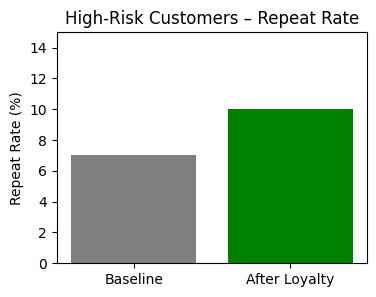

In [ ]:
import matplotlib.pyplot as plt

baseline = 0.07
newrate  = 0.10

plt.figure(figsize=(4,3))
plt.bar(['Baseline','After Loyalty'], [baseline*100, newrate*100], color=['gray','green'])
plt.ylim(0,15)   # zoom in to 0–15%
plt.ylabel('Repeat Rate (%)')
plt.title('High-Risk Customers – Repeat Rate')
plt.show()
